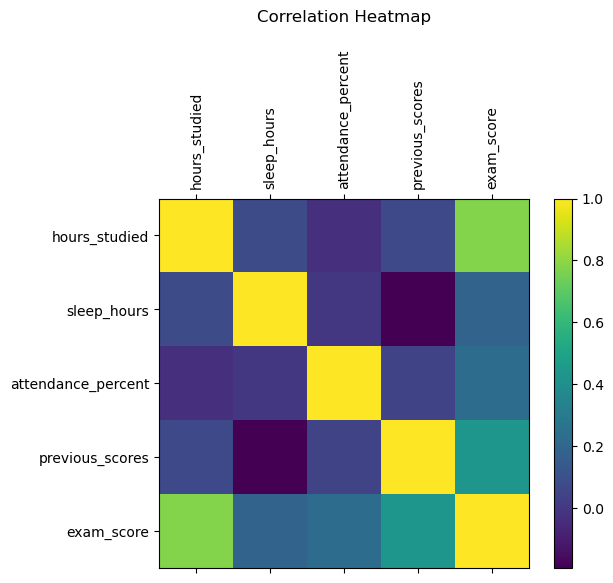

Sample Data:
    hours_studied  sleep_hours  attendance_percent  previous_scores
0            8.0          8.8                72.1               45
1            1.3          8.6                60.7               55
2            4.0          8.2                73.7               86
3            3.5          4.8                95.1               66
4            9.1          6.4                89.8               71


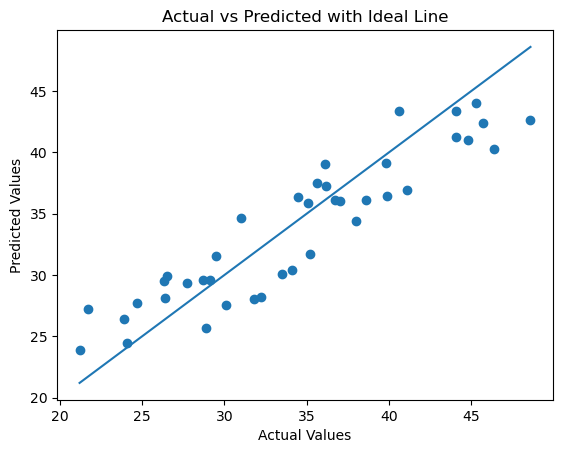


Coefficient: [4.46208582 0.696991   1.06115038 2.23529347]
Intercept: 33.85125000000001

Mean Squared Error: 9.198645447828259
R^2 Score: 0.8266699055055811


In [1]:
import numpy as np  
import pandas as pd  
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso

data = pd.read_csv(r"C:\Users\manee\Downloads\student_exam_scores.csv")
data.columns = data.columns.str.strip()
data.fillna(data.mean(numeric_only=True), inplace=True)
corr = data.corr(numeric_only = True)#compute correlation matrix
#correlation matrix
fig, ax = plt.subplots()
cax = ax.matshow(corr)
fig.colorbar(cax)
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
plt.title("Correlation Heatmap", pad=20)
plt.show()

X = data[['hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores']]
y = data['exam_score']
print("Sample Data:\n", X.head())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = Lasso(alpha = 0.5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

plt.figure()
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted with Ideal Line")
plt.show()

print(f"\nCoefficient: {model.coef_}")
print(f"Intercept: {model.intercept_}")

mse = mean_squared_error(y_test, y_pred)  
r2 = r2_score(y_test, y_pred)  
print(f"\nMean Squared Error: {mse}")  
print(f"R^2 Score: {r2}") 